In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('creditcard.csv')
print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (284807, 31)


In [3]:
window_size = len(df) // 4

week1 = df.iloc[0:window_size]
week2 = df.iloc[window_size:window_size*2]
week3 = df.iloc[window_size*2:window_size*3]
week4 = df.iloc[window_size*3:]

print("Week 1 size:", len(week1))
print("Week 2 size:", len(week2))
print("Week 3 size:", len(week3))
print("Week 4 size:", len(week4))


Week 1 size: 71201
Week 2 size: 71201
Week 3 size: 71201
Week 4 size: 71204


In [4]:
# Copy the weeks so we dont change original data
week2_drift = week2.copy()
week3_drift = week3.copy()
week4_drift = week4.copy()

# Week 2 - slight drift (small noise added)
week2_drift['V1'] = week2_drift['V1'] + np.random.normal(0.5, 0.5, len(week2_drift))
week2_drift['V2'] = week2_drift['V2'] + np.random.normal(0.5, 0.5, len(week2_drift))
week2_drift['Amount'] = week2_drift['Amount'] * 1.1

# Week 3 - moderate drift
week3_drift['V1'] = week3_drift['V1'] + np.random.normal(1.5, 1.0, len(week3_drift))
week3_drift['V2'] = week3_drift['V2'] + np.random.normal(1.5, 1.0, len(week3_drift))
week3_drift['Amount'] = week3_drift['Amount'] * 1.5

# Week 4 - severe drift
week4_drift['V1'] = week4_drift['V1'] + np.random.normal(3.0, 2.0, len(week4_drift))
week4_drift['V2'] = week4_drift['V2'] + np.random.normal(3.0, 2.0, len(week4_drift))
week4_drift['Amount'] = week4_drift['Amount'] * 2.0

print("Drift added successfully!")
print("Week 2 - slight drift")
print("Week 3 - moderate drift")
print("Week 4 - severe drift")

Drift added successfully!
Week 2 - slight drift
Week 3 - moderate drift
Week 4 - severe drift


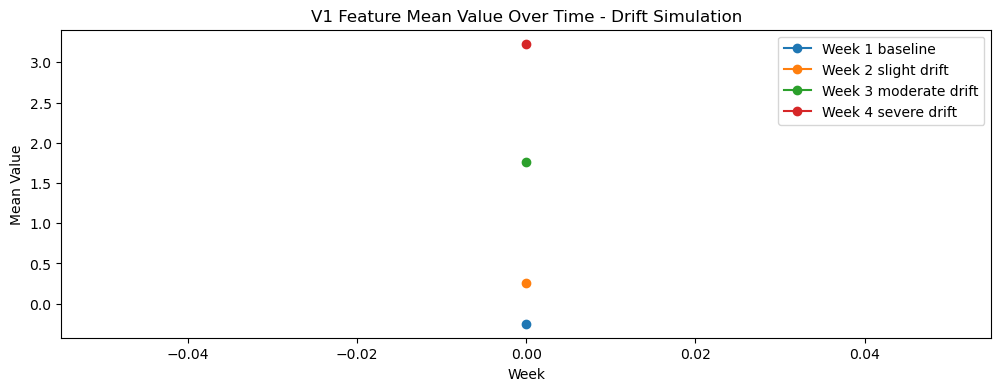

In [5]:
plt.figure(figsize=(12,4))

plt.plot(week1['V1'].mean(), marker='o', label='Week 1 baseline')
plt.plot(week2_drift['V1'].mean(), marker='o', label='Week 2 slight drift')
plt.plot(week3_drift['V1'].mean(), marker='o', label='Week 3 moderate drift')
plt.plot(week4_drift['V1'].mean(), marker='o', label='Week 4 severe drift')

plt.title('V1 Feature Mean Value Over Time - Drift Simulation')
plt.xlabel('Week')
plt.ylabel('Mean Value')
plt.legend()
plt.show()

In [7]:
week1.to_csv('week1_baseline.csv', index=False)
week2_drift.to_csv('week2_drift.csv', index=False)
week3_drift.to_csv('week3_drift.csv', index=False)
week4_drift.to_csv('week4_drift.csv', index=False)

print("All datasets saved successfully!")
print("week1_baseline.csv - saved")
print("week2_drift.csv - saved")
print("week3_drift.csv - saved")
print("week4_drift.csv - saved")


All datasets saved successfully!
week1_baseline.csv - saved
week2_drift.csv - saved
week3_drift.csv - saved
week4_drift.csv - saved
